In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
# Download latest version
import kagglehub
path = kagglehub.dataset_download("nudratabbas/healthcare-fraud-detection-dataset")

print("Path to dataset files:", path)

C:\Users\larin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\larin\.cache\kagglehub\datasets\nudratabbas\healthcare-fraud-detection-dataset\versions\1


In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv(path + "/healthcare_fraud_detection.csv") 

df.head(5)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [4]:
df['approval_ratio'] = df['Approved_Amount']/df['Claim_Amount']

X= df[['Days_Between_Service_and_Claim','approval_ratio']]
y= df[['Is_Fraud']]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

clf = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print(cm) #[[TN,FP],[FN,TP]]

[[1777   57]
 [   2  164]]


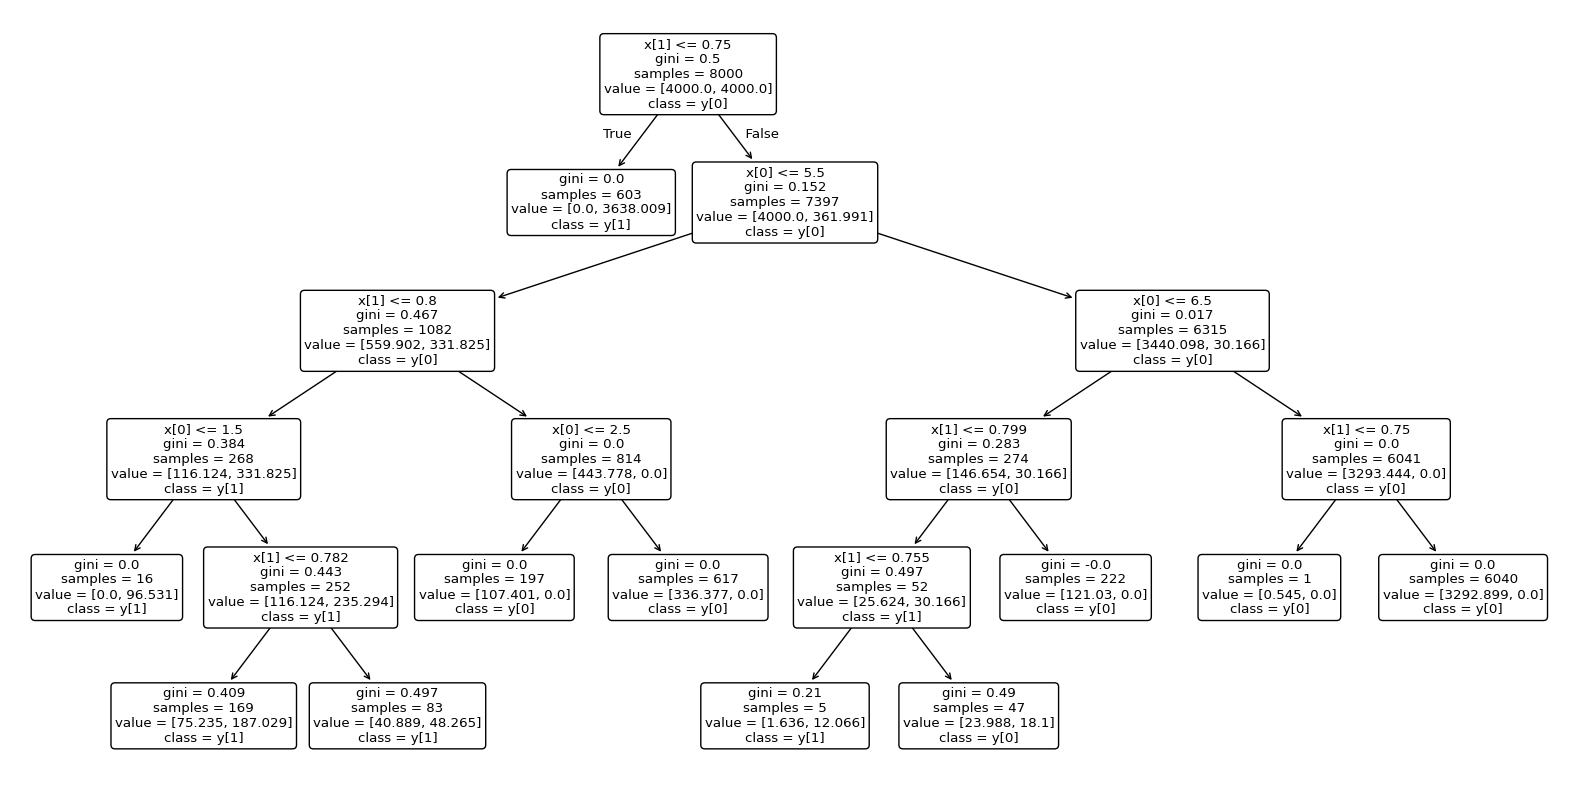

In [15]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(clf, rounded =True,class_names=True)
plt.show()